# sdimg walkthrough

## Goal

Exercise the flat public APIs and verify their image, mask, and representation contracts.

## Setup

Run the notebook top-to-bottom with:
- `../asset/sample_image.png`
- `../asset/sample_mask.png`

In [1]:
import sys
import tempfile
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from sdimg.segment import refine_grabcut, threshold_otsu
from sdimg.image import (
    adjust_brightness_contrast,
    apply_clahe,
    apply_gaussian_blur,
    apply_median_blur,
    convert_to_gray,
    convert_to_rgb,
    decode_image,
    denoise,
    encode_image,
    equalize_histogram,
    is_image,
    make_array_id,
    normalize_minmax,
    normalize_zscore,
    read_image,
    sharpen,
    write_image,
)
from sdimg.mask import (
    apply_morphology,
    compute_distance_transform,
    convert_to_mask,
    count_foreground,
    extract_boundary,
    extract_roi,
    fill_concave_hull,
    fill_convex_hull,
    fill_holes,
    find_bbox,
    find_centroid,
    find_foreground_points,
    is_mask,
    keep_largest_component,
    measure_bbox_area,
)
from sdimg.spatial import (
    crop,
    flip,
    merge_tiles,
    pad_to_square,
    resize,
    resize_to_long_side,
    rotate,
    split_tiles,
)

In [2]:
def display_image(img: np.ndarray) -> np.ndarray:
    if img.ndim == 3 and img.shape[2] == 1:
        return img[..., 0]
    return img


def show_grid(
    items: list[tuple[str, np.ndarray]],
    *,
    cols: int = 3,
    figsize: tuple[int, int] = (15, 10),
    as_mask: bool = False,
) -> None:
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.axis("off")

    for ax, (title, img) in zip(axes, items):
        ax.set_title(title)
        if as_mask or img.ndim == 2:
            ax.imshow(
                img,
                cmap="gray",
                vmin=0 if as_mask else None,
                vmax=1 if as_mask else None,
            )
        else:
            ax.imshow(display_image(img))

    plt.tight_layout()
    plt.show()


def show_images(items: list[tuple[str, np.ndarray]], **kwargs) -> None:
    show_grid(items, as_mask=False, **kwargs)


def show_masks(items: list[tuple[str, np.ndarray]], **kwargs) -> None:
    show_grid(items, as_mask=True, **kwargs)

In [3]:
image_path = Path("../asset/sample_image.png")
mask_path = Path("../asset/sample_mask.png")

if not image_path.exists():
    raise FileNotFoundError(f"{image_path} not found")
if not mask_path.exists():
    raise FileNotFoundError(f"{mask_path} not found")

image = read_image(image_path)
mask_raw = read_image(mask_path)[..., 0]

gray = convert_to_gray(image)
base_mask = convert_to_mask(mask_raw)

print("image:", image.shape, image.dtype)
print("gray:", gray.shape, gray.dtype)
print("mask:", base_mask.shape, base_mask.dtype, np.unique(base_mask))

image: (1080, 1080, 3) uint8
gray: (1080, 1080) uint8
mask: (1080, 1080) uint8 [0 1]


## Steps

### 1. Inspect base data


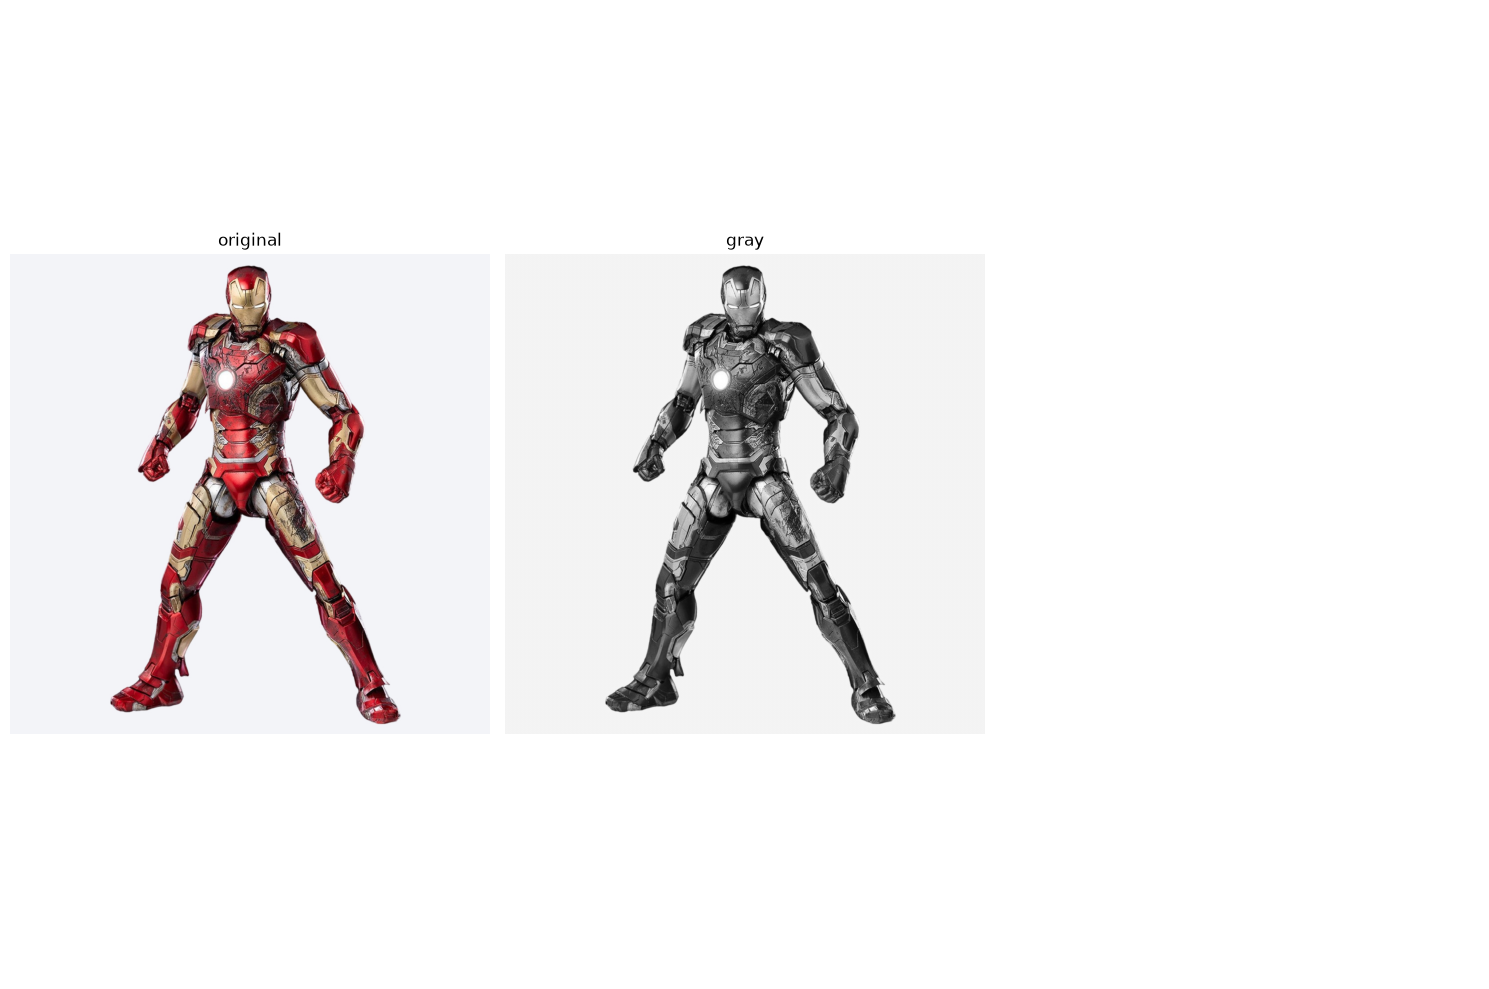

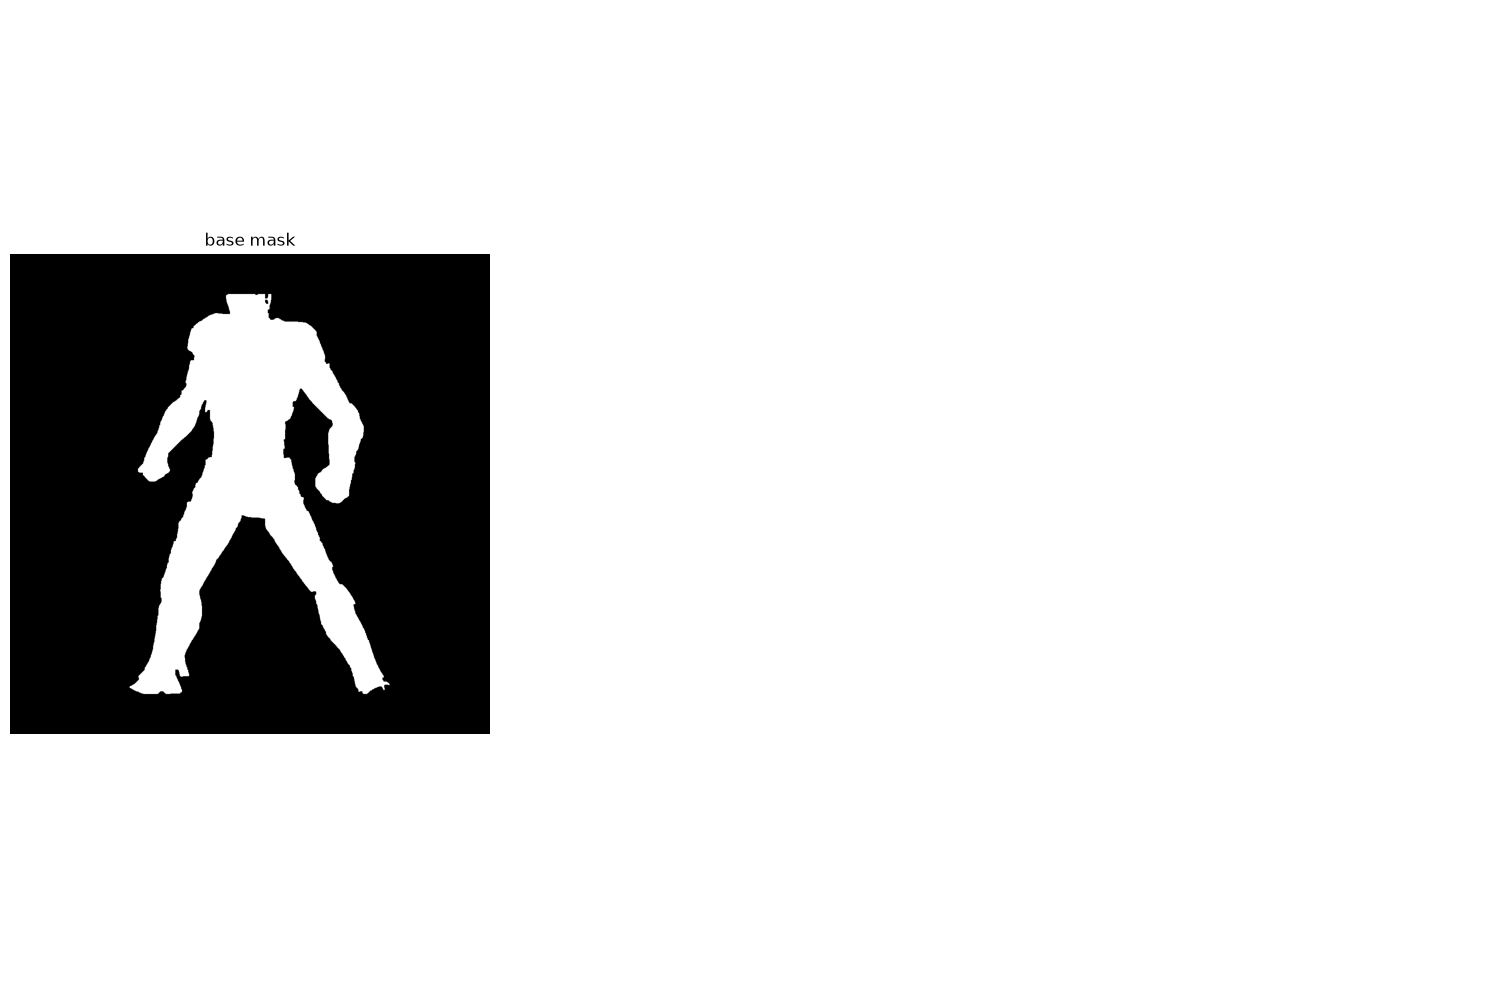

In [4]:
show_images(
    [
        ("original", image),
        ("gray", gray),
    ]
)
show_masks([("base mask", base_mask)])

### 2. Round-trip image utilities


In [5]:
encoded = encode_image(image)
decoded = decode_image(encoded)
image_id = make_array_id(image, prefix="img_", length=12)

with tempfile.TemporaryDirectory() as tmpdir:
    roundtrip_path = Path(tmpdir) / "roundtrip.png"
    write_image(roundtrip_path, image)
    roundtrip = read_image(roundtrip_path)

print("id:", image_id)
print("encoded chars:", len(encoded))
print("decode matches:", np.array_equal(decoded, image))
print("write_image/read_image matches:", np.array_equal(roundtrip, image))

id: img_3377c9787a9f
encoded chars: 611812
decode matches: True
write_image/read_image matches: True


### 3. Check conversion contracts


is_image(image): True
is_mask(base_mask): True
rgb_from_gray: (1080, 1080, 3) uint8
normalized_mask unique: [0 1]


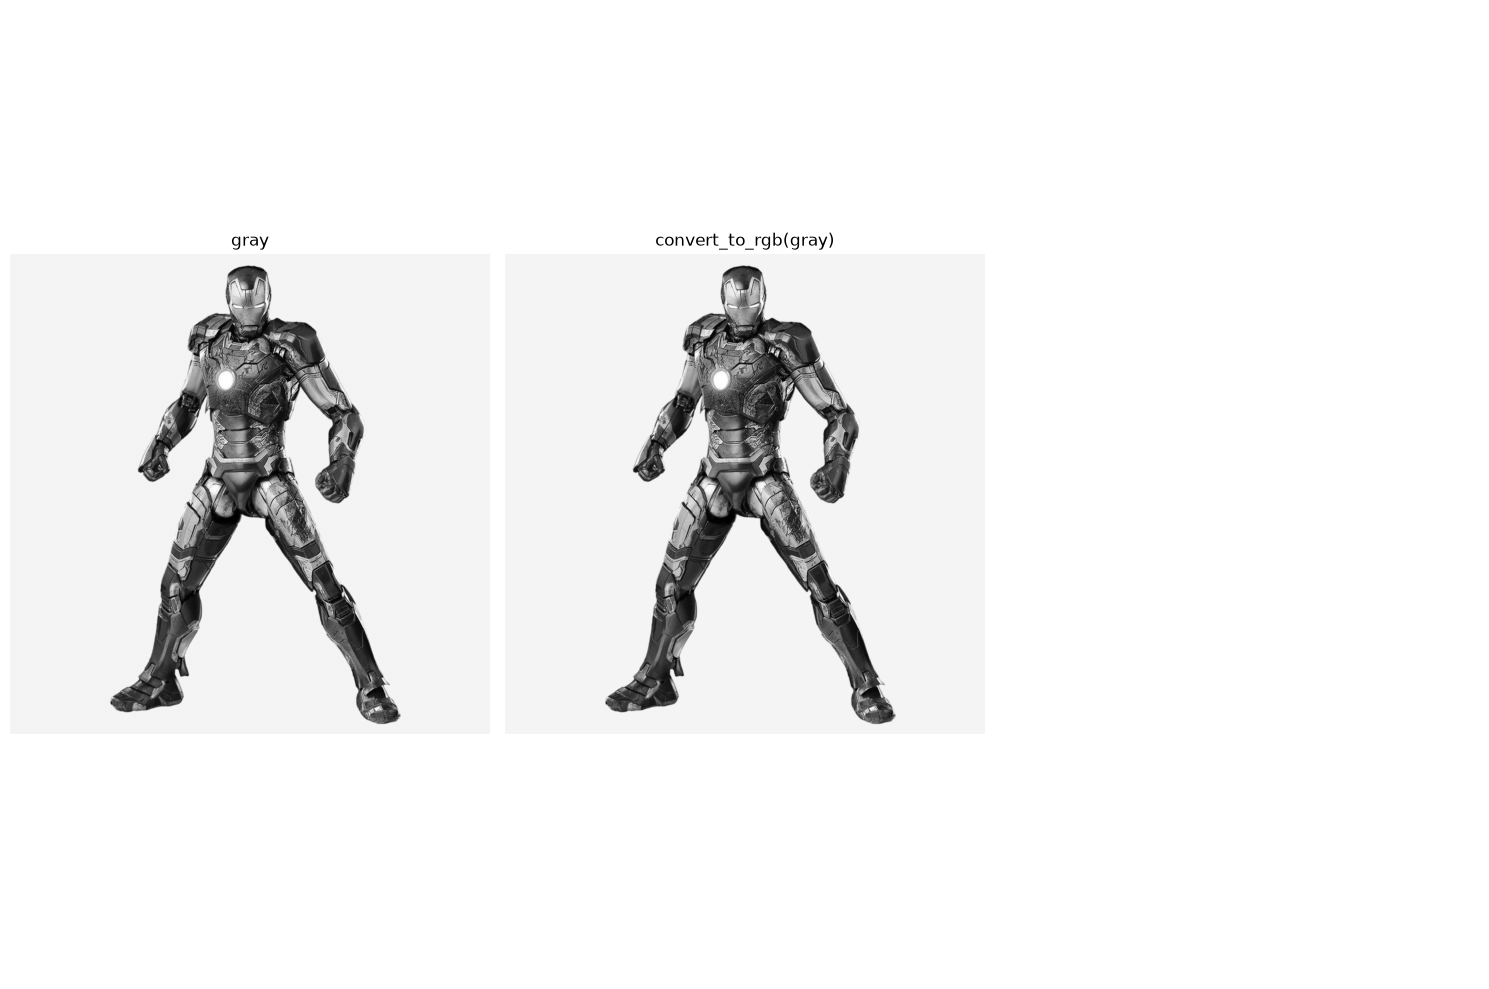

In [6]:
rgb_from_gray = convert_to_rgb(gray)
normalized_mask = convert_to_mask(base_mask * 255)

print("is_image(image):", is_image(image))
print("is_mask(base_mask):", is_mask(base_mask))
print("rgb_from_gray:", rgb_from_gray.shape, rgb_from_gray.dtype)
print("normalized_mask unique:", np.unique(normalized_mask))

show_images(
    [
        ("gray", gray),
        ("convert_to_rgb(gray)", rgb_from_gray),
    ]
)

### 4. Process images


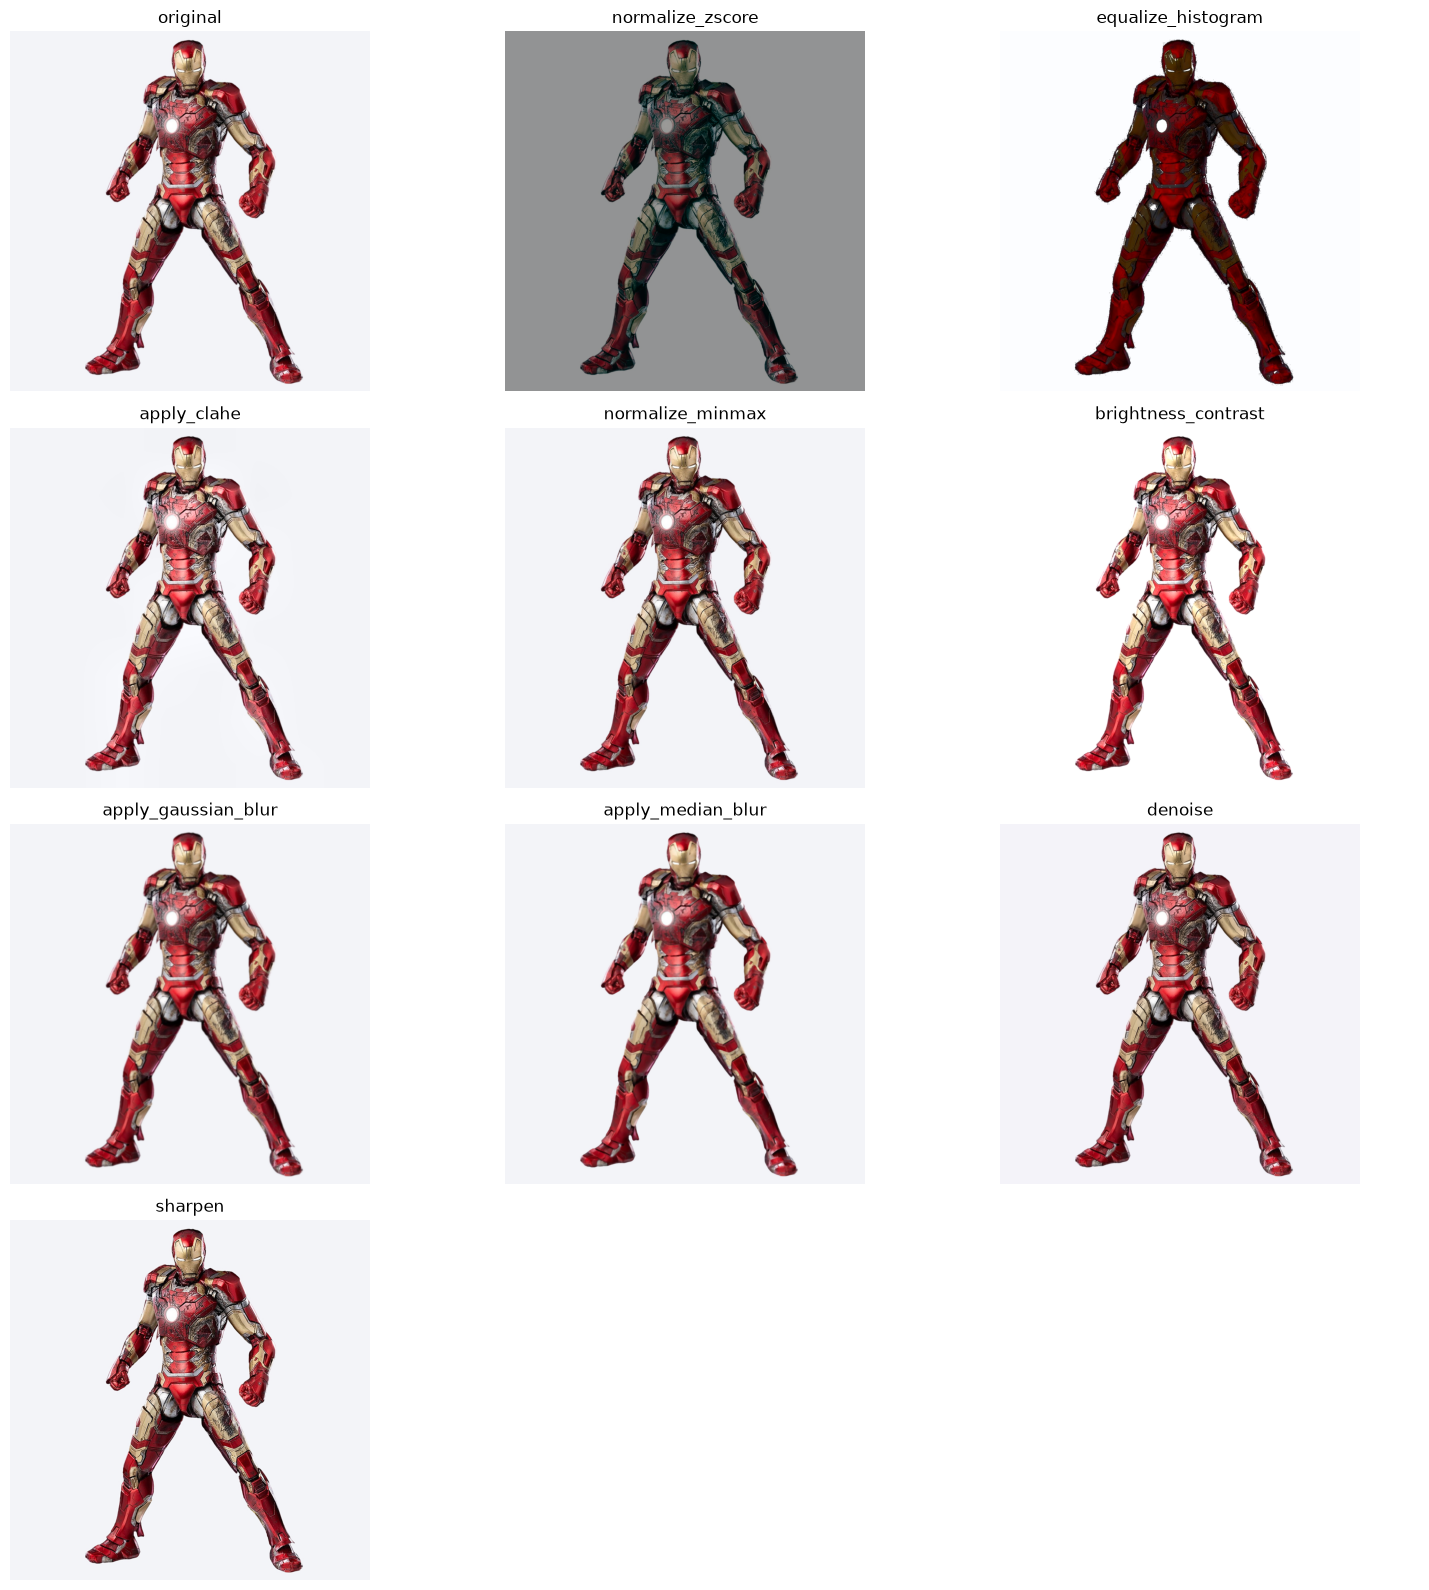

In [7]:
image_results = [
    ("normalize_zscore", normalize_zscore(image)),
    ("equalize_histogram", equalize_histogram(image)),
    ("apply_clahe", apply_clahe(image)),
    ("normalize_minmax", normalize_minmax(image)),
    (
        "brightness_contrast",
        adjust_brightness_contrast(image, brightness=0.1, contrast=0.2),
    ),
    ("apply_gaussian_blur", apply_gaussian_blur(image, (5, 5), 1.2)),
    ("apply_median_blur", apply_median_blur(image, 5)),
    ("denoise", denoise(image)),
    ("sharpen", sharpen(image, amount=1.0)),
]

show_images([("original", image), *image_results], cols=3, figsize=(15, 16))

### 5. Process masks


foreground points (x, y): (216270, 2)
bbox: (269, 90, 854, 990)
foreground area: 216270
bbox area: 526500
extract_roi shape, bbox: ((900, 585), (269, 90, 854, 990))
centroid (x, y): (547.1817311693716, 499.3591159199149)


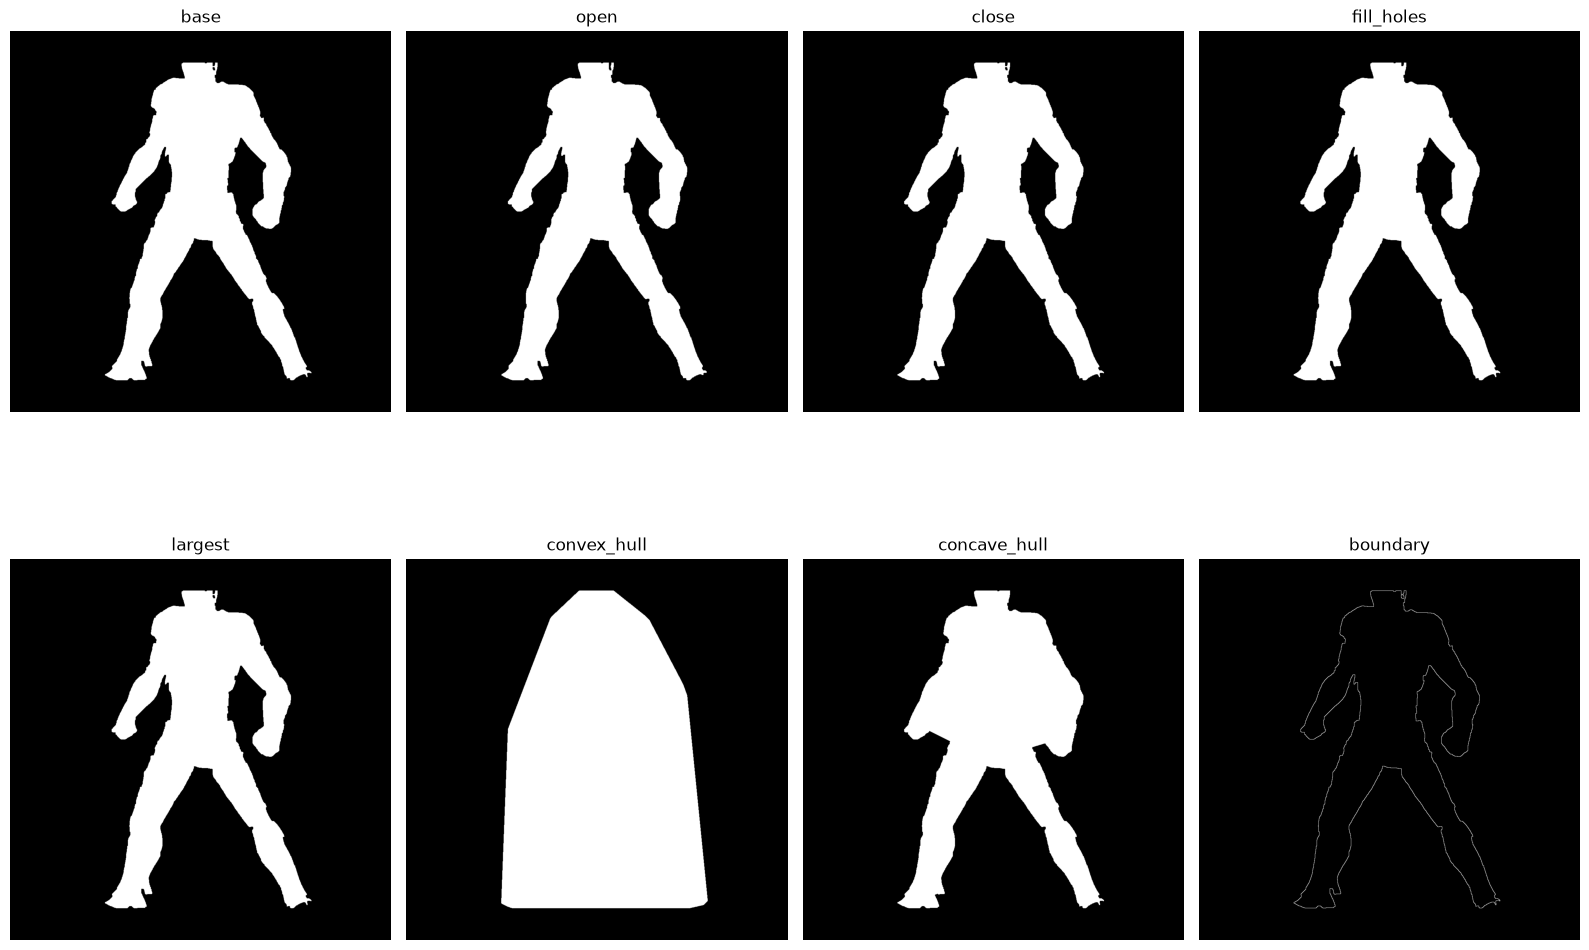

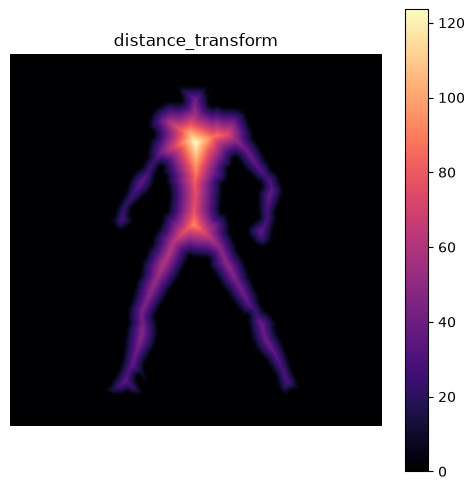

In [8]:
mask_ops = [
    ("open", apply_morphology(base_mask, "open", (5, 5), 1)),
    ("close", apply_morphology(base_mask, "close", (5, 5), 1)),
    ("fill_holes", fill_holes(base_mask)),
    ("largest", keep_largest_component(base_mask)),
    ("convex_hull", fill_convex_hull(base_mask)),
    ("concave_hull", fill_concave_hull(base_mask)),
    ("boundary", extract_boundary(base_mask)),
]
mask_distance = compute_distance_transform(base_mask)
bbox = find_bbox(base_mask)
roi_result = extract_roi(base_mask)

print("foreground points (x, y):", find_foreground_points(base_mask).shape)
print("bbox:", bbox)
print("foreground area:", count_foreground(base_mask))
print("bbox area:", measure_bbox_area(bbox))
print("extract_roi shape, bbox:", (roi_result[0].shape, roi_result[1]) if roi_result else None)
print("centroid (x, y):", find_centroid(base_mask))

show_masks([("base", base_mask), *mask_ops], cols=4, figsize=(16, 12))

plt.figure(figsize=(6, 6))
plt.title("distance_transform")
plt.imshow(mask_distance, cmap="magma")
plt.axis("off")
plt.colorbar()
plt.show()

### 6. Transform spatial data


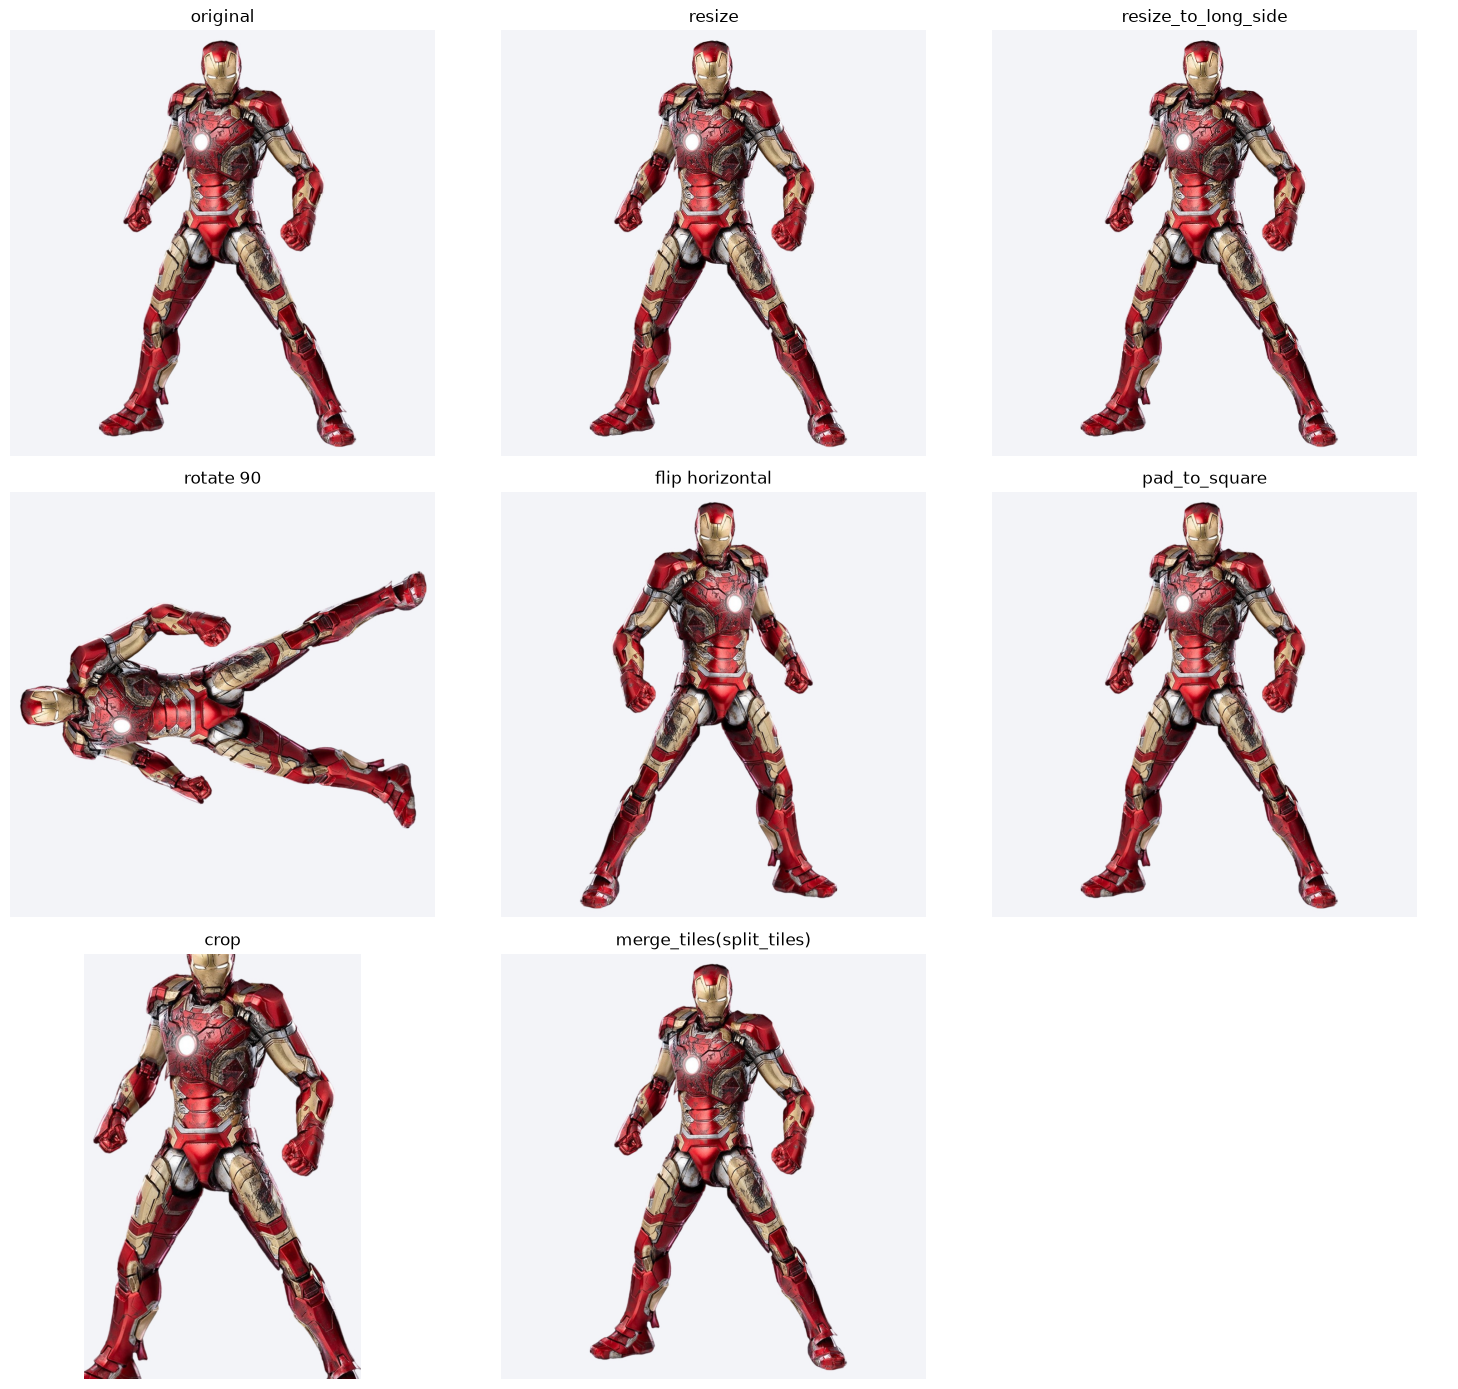

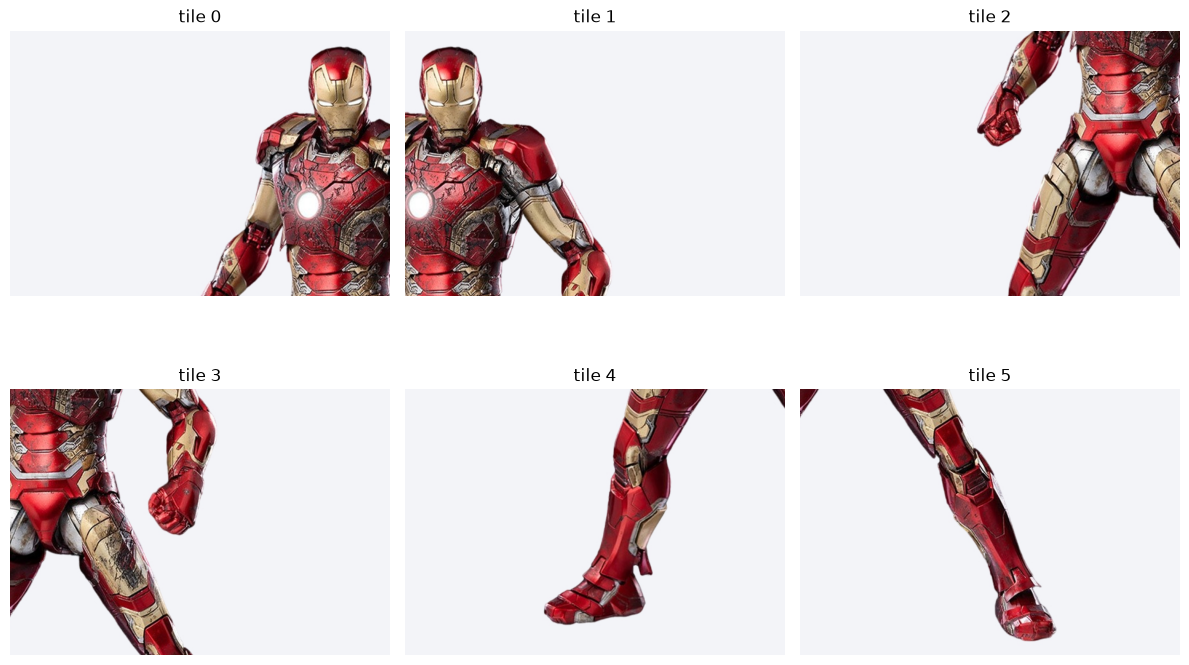

In [9]:
bbox = find_bbox(base_mask)
if bbox is None:
    raise ValueError("base_mask is empty")

resized = resize(array=image, height=512)
resized_long = resize_to_long_side(array=image, long_side=512)
rotated = rotate(array=image, degrees=90)
flipped = flip(array=image, direction="horizontal")
padded, pad_bbox = pad_to_square(array=image, return_bbox=True)
cropped = crop(array=image, bbox=bbox)
tiles, tile_metadata = split_tiles(
    array=image, grid=(2, 3), overlap=0.25, return_metadata=True
)
merged = merge_tiles(tiles=tiles, metadata=tile_metadata)

show_images(
    [
        ("original", image),
        ("resize", resized),
        ("resize_to_long_side", resized_long),
        ("rotate 90", rotated),
        ("flip horizontal", flipped),
        ("pad_to_square", padded),
        ("crop", cropped),
        ("merge_tiles(split_tiles)", merged),
    ],
    cols=3,
    figsize=(15, 14),
)

show_images(
    [(f"tile {i}", tile) for i, tile in enumerate(tiles[:6])],
    cols=3,
    figsize=(12, 8),
)

#### 6.1 Apply paired image and mask operations


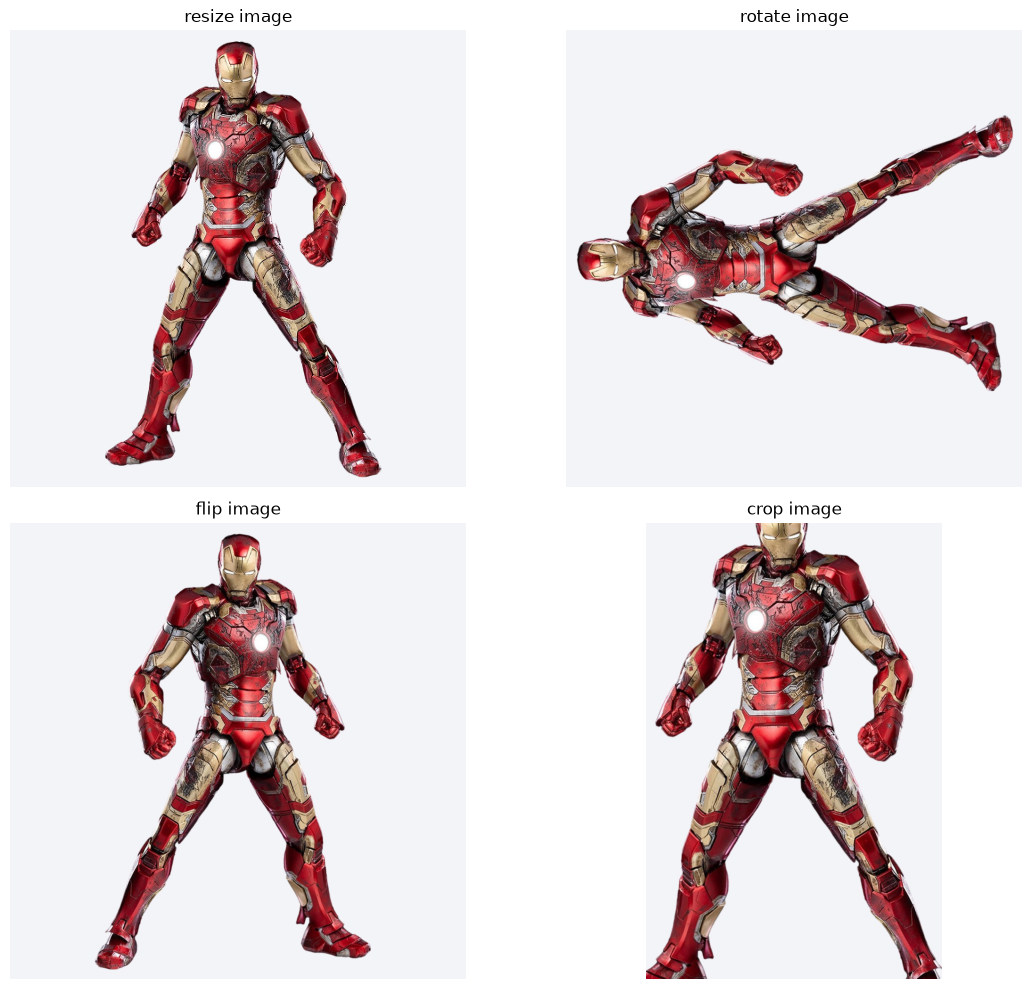

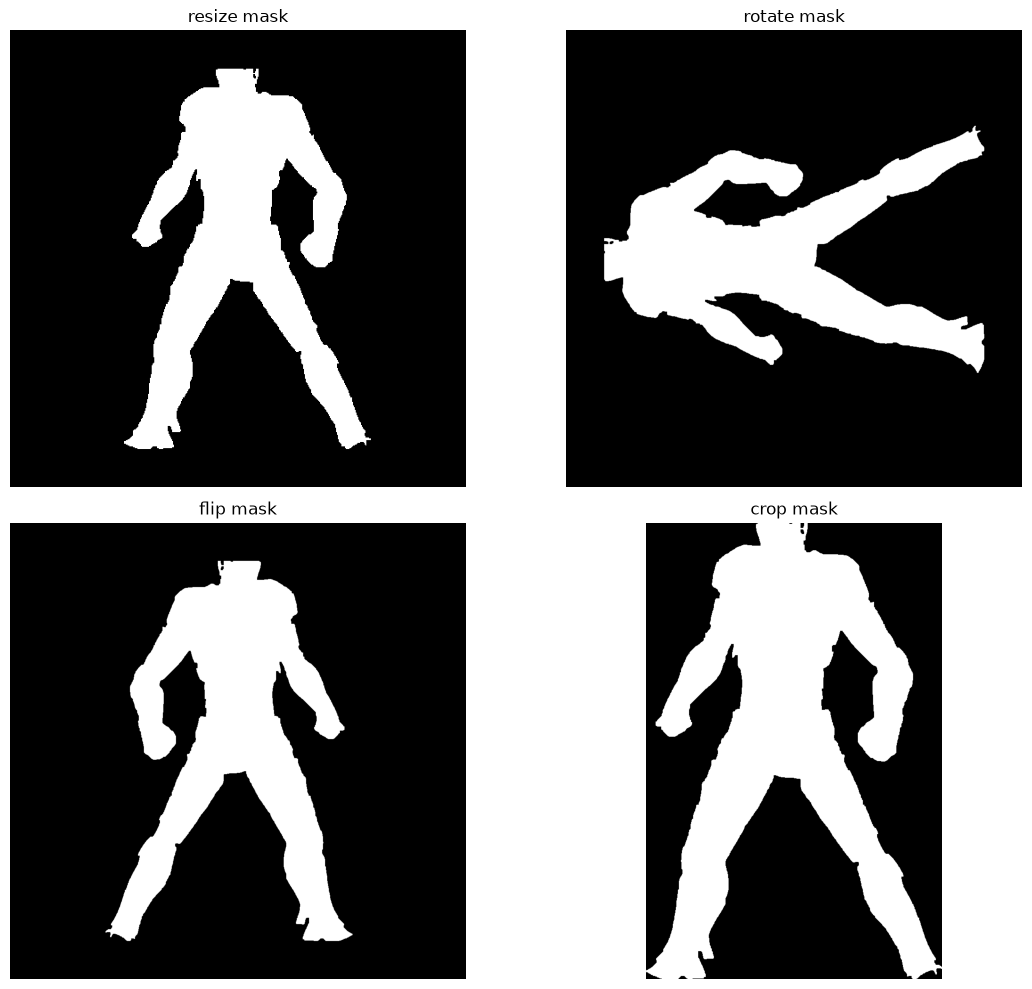

In [10]:
bbox = find_bbox(base_mask)
if bbox is None:
    raise ValueError("base_mask is empty")

img_resized = resize(array=image, height=512)
mask_resized = resize(array=base_mask, height=512, interpolation=cv2.INTER_NEAREST)

img_rotated = rotate(array=image, degrees=90)
mask_rotated = rotate(array=base_mask, degrees=90)

img_flipped = flip(array=image, direction="horizontal")
mask_flipped = flip(array=base_mask, direction="horizontal")

img_cropped = crop(array=image, bbox=bbox)
mask_cropped = crop(array=base_mask, bbox=bbox)

show_images(
    [
        ("resize image", img_resized),
        ("rotate image", img_rotated),
        ("flip image", img_flipped),
        ("crop image", img_cropped),
    ],
    cols=2,
    figsize=(12, 10),
)

show_masks(
    [
        ("resize mask", mask_resized),
        ("rotate mask", mask_rotated),
        ("flip mask", mask_flipped),
        ("crop mask", mask_cropped),
    ],
    cols=2,
    figsize=(12, 10),
)

### 7. Segment images


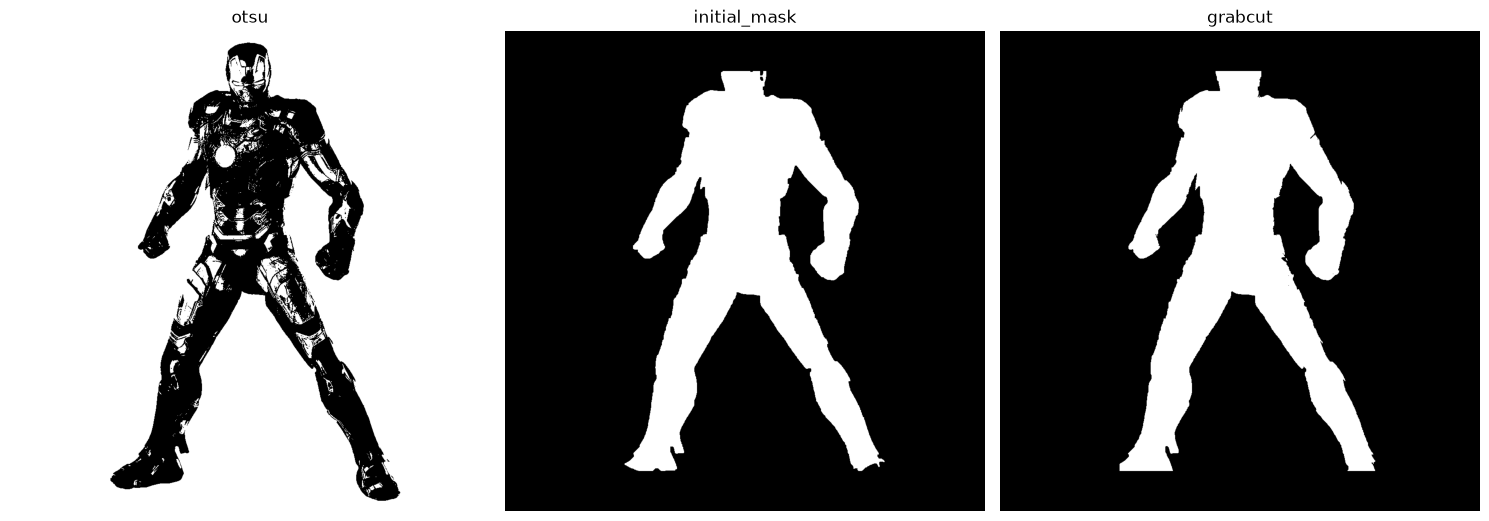

In [11]:
otsu_mask = threshold_otsu(image=image)

grabcut_mask = refine_grabcut(image=image, mask=base_mask)

show_masks(
    [
        ("otsu", otsu_mask),
        ("initial_mask", base_mask),
        ("grabcut", grabcut_mask),
    ],
    cols=3,
    figsize=(15, 6),
)

## Checks

Verify the representation-preservation and full-mask segmentation contracts exercised above.

In [12]:
alpha = np.arange(image.shape[0] * image.shape[1], dtype=np.uint8).reshape(image.shape[:2])
rgba = np.concatenate([image, alpha[..., None]], axis=2)
filtered_rgba = apply_gaussian_blur(rgba, kernel_size=(3, 3), sigma_x=1.0)

mask_tiles, mask_metadata = split_tiles(
    base_mask.astype(bool), grid=2, overlap=0.25, return_metadata=True
)
merged_bool_mask = merge_tiles(mask_tiles, mask_metadata)

assert np.array_equal(decoded, image)
assert np.array_equal(roundtrip, image)
assert np.array_equal(filtered_rgba[..., 3], alpha)
assert merged_bool_mask.dtype == np.bool_
assert np.array_equal(merged_bool_mask, base_mask.astype(bool))
assert grabcut_mask.shape == image.shape[:2]
assert set(np.unique(grabcut_mask).tolist()) <= {0, 1}

print("All public API checks passed.")

All public API checks passed.


## Next Steps

Use the same flat domain imports with your own RGB images and image-sized binary masks.